In [1]:
import lightgbm as lgb
import numpy as np
from load_data import load_data_with_folds, get_fold_data
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
from pandas.util.version import Infinity


In [2]:
def calculate_tree_scores(booster, shap_values, X_train):
    # Compute mean absolute SHAP values per feature
    total_shap_values = shap_values.sum(axis=0)[:, :-1]
    mean_abs_shap_values = np.mean(np.abs(total_shap_values), axis=0)
    sum_mean_abs_shap_values = np.sum(mean_abs_shap_values)

    prob_shap_values = mean_abs_shap_values / sum_mean_abs_shap_values

    tree_scores = []

    for tree in booster.dump_model()['tree_info']:
        feature_split_count = get_feature_split_count(tree['tree_structure'], X_train)
        tree_score = np.sum(prob_shap_values * feature_split_count)
        tree_scores.append(tree_score)

    tree_scores = np.array(tree_scores)
    sum_scores = np.sum(tree_scores)

    tree_scores = tree_scores / sum_scores

    return tree_scores

def get_feature_split_count(tree_structure, X_train):
    feature_split_count = np.zeros(len(X_train.columns))

    def extract_feature_split_count(tree_structure):
        if 'leaf_index' in tree_structure:
            return
        
        feature_split_count[tree_structure['split_feature']] += 1

        extract_feature_split_count(tree_structure['left_child'])
        extract_feature_split_count(tree_structure['right_child'])

    extract_feature_split_count(tree_structure)

    return feature_split_count

In [3]:
def create_uniqe_seed(drop_seed, fold_idx, iteration):
    if drop_seed is not None:
        return drop_seed

    return fold_idx * 10000 + iteration

def dump_shrinkage(booster):
    tree_info = booster.dump_model()['tree_info']
    shrinkage = []
    for i, tree in enumerate(tree_info):
        shrinkage.append(tree["shrinkage"])

    return shrinkage

In [4]:
def create_shap_drop_callback(X_train, fold_idx, drop_rate, skip_drop, max_drop, use_shap, 
                              shap_values_container, drop_seed=None):
    
    def shap_drop_callback(iteration, userdata):
        booster = userdata
        
        num_trees = booster.num_trees()
        
        # Skip drop if no trees yet
        if num_trees <= 0:
            booster.set_dart_drop_indices([])
            return

        current_shap = shap_values_container[0]

        seed = create_uniqe_seed(drop_seed, fold_idx, iteration)

        # Determine drop indices
        drop_indices = determine_drop_indices(
            booster=booster,
            num_trees=num_trees,
            drop_rate=drop_rate,
            skip_drop=skip_drop,
            max_drop=max_drop,
            X_train=X_train,
            previous_shap_values=current_shap,
            use_shap=use_shap,
            drop_seed=seed
        )

        booster.set_dart_drop_indices(drop_indices)
        
    return shap_drop_callback

def determine_drop_indices(booster, num_trees, drop_rate, skip_drop, max_drop, X_train,
                          previous_shap_values=None, use_shap=False, drop_seed=None):
    rng = np.random.RandomState(drop_seed)
    if rng.rand() < skip_drop:
        return []
    
    effective_drop_rate = drop_rate
    if max_drop > 0 and num_trees > 0:
        effective_drop_rate = min(drop_rate, max_drop / num_trees)

    drop_indices = []

    if use_shap and previous_shap_values is not None:
        tree_scores = calculate_tree_scores(booster, previous_shap_values, X_train)
        
        for i in range(num_trees):
            drop_prob = effective_drop_rate * tree_scores[i] * num_trees
            if rng.rand() < drop_prob:
                drop_indices.append(i)
                if max_drop > 0 and len(drop_indices) >= max_drop:
                    break
        
    else:
        for i in range(num_trees):
            if rng.rand() < effective_drop_rate:
                drop_indices.append(i)

                if max_drop > 0 and len(drop_indices) >= max_drop:
                    break
    
    return drop_indices

def calculate_shap_values_old(booster, X_train):
    model_str = booster.model_to_string()
    snap_booster = lgb.Booster(model_str=model_str)

    n_trees = snap_booster.num_trees()
    shap_prev = 0
    per_tree = []

    for k in range(1, n_trees + 1):
        shap_k = snap_booster.predict(X_train, num_iteration=k, pred_contrib=True)
        per_tree.append(shap_k - shap_prev)
        shap_prev = shap_k

    del snap_booster

    return np.stack(per_tree, axis=0)

def calculate_shap_values_initial(booster, X_train):
    model_str = booster.model_to_string()
    snap = lgb.Booster(model_str=model_str)

    shrinkage = dump_shrinkage(snap)
    n_trees = snap.num_trees()
    
    assert n_trees == 1

    shap_values = snap.predict(
        X_train,
        num_iteration=n_trees,
        pred_contrib=True
    )

    per_tree_shap = shap_values[None, ...]

    del snap
    return per_tree_shap, np.array(shrinkage)

def update_shap_incremental(booster, X_train, per_tree_shap_prev, shrinkage_prev):
    model_str = booster.model_to_string()
    snap = lgb.Booster(model_str=model_str)

    shrinkage_next = np.array(dump_shrinkage(snap))
    n_trees_next = snap.num_trees()
    n_trees_prev = per_tree_shap_prev.shape[0]

    assert n_trees_next > n_trees_prev

    shap_total_next = snap.predict(
        X_train,
        num_iteration=n_trees_next,
        pred_contrib=True
    )

    # Rescale old trees where shrinkage changed
    ratios = shrinkage_next[:n_trees_prev] / shrinkage_prev[:n_trees_prev]
    per_tree_shap_rescaled = per_tree_shap_prev * ratios[:, None, None]

    # New tree SHAP = total - sum(rescaled old)
    sum_old = per_tree_shap_rescaled.sum(axis=0)
    shap_new_tree = shap_total_next - sum_old

    per_tree_shap_next = np.concatenate(
        [per_tree_shap_rescaled, shap_new_tree[None, ...]],
        axis=0
    )

    del snap
    return per_tree_shap_next, shrinkage_next

def compare_shap_values(shap_old, shap_new, rtol=1e-6, atol=1e-8):
    report = {}

    report["same_shape"] = (shap_old.shape == shap_new.shape)
    if not report["same_shape"]:
        report["all_close"] = False
        report["max_abs_diff"] = np.inf
        report["per_tree_all_close"] = []
        report["per_tree_max_abs_diff"] = []
        return report

    n_trees = shap_old.shape[0]

    per_tree_all_close = []
    per_tree_max_abs_diff = []

    for t in range(n_trees):
        diff = shap_old[t] - shap_new[t]
        max_abs = np.max(np.abs(diff))
        ok = np.allclose(shap_old[t], shap_new[t], rtol=rtol, atol=atol)
        per_tree_all_close.append(ok)
        per_tree_max_abs_diff.append(float(max_abs))

    report["per_tree_all_close"] = per_tree_all_close
    report["per_tree_max_abs_diff"] = per_tree_max_abs_diff

    diff_all = shap_old - shap_new
    report["max_abs_diff"] = float(np.max(np.abs(diff_all)))
    report["all_close"] = np.allclose(shap_old, shap_new, rtol=rtol, atol=atol)

    return report

def compare_sample_vs_full(shap_full, shap_sample):
    # Collapse over trees and rows: mean |SHAP| per feature
    mean_abs_full   = np.mean(np.abs(shap_full), axis=(0, 1))   # (n_features,)
    mean_abs_sample = np.mean(np.abs(shap_sample), axis=(0, 1)) # (n_features,)

    # Absolute and relative differences
    abs_diff = mean_abs_sample - mean_abs_full
    rel_diff = abs_diff / (np.abs(mean_abs_full) + 1e-12)

    # Rank correlation of feature importance
    rank_full   = np.argsort(np.argsort(-mean_abs_full))
    rank_sample = np.argsort(np.argsort(-mean_abs_sample))
    spearman, _ = spearmanr(rank_full, rank_sample)

    report = {
        "mean_abs_full": mean_abs_full,
        "mean_abs_sample": mean_abs_sample,
        "abs_diff": abs_diff,
        "rel_diff": rel_diff,
        "max_abs_diff": float(np.max(np.abs(abs_diff))),
        "max_rel_diff": float(np.max(np.abs(rel_diff))),
        "spearman_rank_corr": float(spearman),
    }
    return report
    



In [5]:
def run_single_fold(X, y, patient_ids, fold_indices, fold_idx, params, num_iterations, use_lightgbm_default, use_shap):
    X_train, y_train, X_test, y_test = get_fold_data(
        X, y, patient_ids, fold_indices, fold_idx
    )

    booster = create_booster_with_callback(
        X_train, y_train, X_test, y_test, params, use_lightgbm_default, use_shap, fold_idx=fold_idx
    )

    train_fold_model(booster, num_iterations, use_shap, X_train)

    results = evaluate_fold(booster, X_train, y_train, X_test, y_test, fold_idx)

    return results

def create_booster_with_callback(X_train, y_train, X_test, y_test, params, use_lightgbm_default, use_shap, fold_idx=None):
    train_data = lgb.Dataset(X_train, label=y_train)
    test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

    booster = lgb.Booster(params, train_set=train_data)
    booster.add_valid(test_data, "valid")

    shap_values_container = [None]

    if not use_lightgbm_default:
        callback = create_shap_drop_callback(
            X_train=X_train,
            fold_idx=fold_idx,
            drop_rate=params.get('drop_rate', 0.1),
            skip_drop=params.get('skip_drop', 0.5),
            max_drop=params.get('max_drop', 0),
            use_shap=use_shap,
            shap_values_container=shap_values_container
        )
        booster.set_dart_callback(callback, user_data=booster)

    booster._shap_values_container = shap_values_container

    return booster

def train_fold_model(booster, num_iterations, use_shap, X_train):
    X_shap = X_train.sample(n=100, random_state=42)
    
    shap_values_container = getattr(booster, '_shap_values_container', [None])
    shrinkage = None

    for i in range(num_iterations):
        booster.update()

        if use_shap:
            if i == 0:
                per_tree_shap, shrinkage = calculate_shap_values_initial(booster, X_shap)
            else:
                per_tree_shap, shrinkage = update_shap_incremental(
                    booster,
                    X_shap,
                    shap_values_container[0],
                    shrinkage
                )

            # report = compare_sample_vs_full(shap_values, per_tree_shap)
            
            shap_values_container[0] = per_tree_shap

def evaluate_fold(booster, X_train, y_train, X_test, y_test, fold_idx):
    y_pred_train = booster.predict(X_train)
    y_pred_test = booster.predict(X_test)
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    return {
        'fold_idx': fold_idx,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_samples': len(X_train),
        'test_samples': len(X_test)
    }

def create_report(shap_slow, shap_fast, iteration):
    report = compare_shap_values(shap_slow, shap_fast)

    print(f"Iteration {iteration}")
    print(f"  same_shape: {report['same_shape']}")
    print(f"  all_close:  {report['all_close']}")
    print(f"  max_abs_diff: {report['max_abs_diff']:.3e}")

    # Optional: print per-tree details if something deviates
    if not report["all_close"]:
        for t, (ok, max_d) in enumerate(
            zip(report["per_tree_all_close"], report["per_tree_max_abs_diff"])
        ):
            if not ok:
                print(f"    Tree {t}: max_abs_diff={max_d:.3e}")


In [6]:
def print_cv_summary(fold_results):
    print("\n" + "=" * 60)
    print("CROSS-VALIDATION SUMMARY")
    print("=" * 60)
    for result in fold_results:
        print(f"Fold {result['fold_idx']:2d}: Train MSE={result['train_mse']:.4f}, Test MSE={result['test_mse']:.4f} (Train: {result['train_samples']:5d}, Test: {result['test_samples']:5d})")
    avg_test_mse = np.mean([r['test_mse'] for r in fold_results])
    std_test_mse = np.std([r['test_mse'] for r in fold_results])
    print(f"\nAverage Test MSE: {avg_test_mse:.4f} ± {std_test_mse:.4f}")
    return avg_test_mse

In [7]:
def compare_shap_across_iterations(results, rtol=1e-5, atol=1e-8):
    iters = sorted(results.keys())
    comparisons = {}

    for i in range(len(iters) - 1):
        iter_prev = iters[i]
        iter_curr = iters[i + 1]

        sv_prev = results[iter_prev]["shap_values"]
        sv_curr = results[iter_curr]["shap_values"]

        n_trees_prev = sv_prev.shape[0]
        n_trees_curr = sv_curr.shape[0]
        n_common = min(n_trees_prev, n_trees_curr)

        per_tree_equal = []
        for t in range(n_common):
            equal = np.allclose(sv_prev[t], sv_curr[t], rtol=rtol, atol=atol)
            per_tree_equal.append(equal)

        all_equal = all(per_tree_equal)

        comparisons[(iter_prev, iter_curr)] = {
            "per_tree_equal": per_tree_equal,
            "all_equal": all_equal,
        }

    return comparisons

def shap_values_equal(values_1, values_2):
    return np.array_equal(values_1, values_2)

In [8]:
def run_grid_search(base_params, grid, use_lightgbm_default, use_shap, n_folds):
    X, y, patient_ids, fold_indices = load_data_with_folds(
        file_path="../data/slice_localization_data.csv",
        target_col="reference",
        drop_cols=["patientId"],
        n_folds=n_folds,
    )

    all_results = []

    for i, params in enumerate(grid):
        print(f"Running search: {i}/{len(grid)}")
        full_params = {**base_params, **params}

        fold_results = []
        for fold_idx in range(n_folds):
            result = run_single_fold(X, y, patient_ids, fold_indices, fold_idx, full_params, 100, use_lightgbm_default, use_shap)
            fold_results.append(result)
        
        # Store results for this parameter combination
        all_results.append({
            'full_params': full_params,
            'fold_results': fold_results,
        })
    
    return all_results


import json
from datetime import datetime

def save_grid_results(results, output_file, use_lightgbm_default=None, use_shap=None, n_folds=None):
    """Save grid search results to a JSON file."""
    output_data = {
        'timestamp': datetime.now().isoformat(),
        'use_lightgbm_default': use_lightgbm_default,
        'use_shap': use_shap,
        'n_folds': n_folds,
        'results': results
    }
    with open(output_file, 'w') as f:
        json.dump(output_data, f, indent=2)
    print(f"Results saved to {output_file}")
        

In [9]:
# Grid search code - commented out for SHAP sample size comparison experiment
# from sklearn.model_selection import ParameterGrid

# base_params = {
#     "objective": "regression",
#     "boosting_type": "dart",
#     "metric": "mse",
#     "verbose": -1,
#     "max_depth": 10
# }

# param_distributions = {
#     "learning_rate": [0.1, 0.2, 0.3],
#     "num_leaves": [50, 100, 200],
#     "feature_fraction_bynode": [0.2, 0.4],
#     "drop_rate": [0.025, 0.05, 0.1, 0.2],
# }

# grid = ParameterGrid(param_distributions)

# use_lightgbm_default = True
# use_shap = False

# grid_results = run_grid_search(base_params, grid, use_lightgbm_default, use_shap, 10)
# save_grid_results(grid_results, "../results/grid_search_results_default_100.json", use_lightgbm_default=use_lightgbm_default, use_shap=use_shap, n_folds=10)


In [10]:
import time

def train_with_shap_comparison(X_train, y_train, X_test, y_test, params, num_iterations):
    """
    Train a model and compute SHAP values for multiple sample sizes.
    Returns timing info per iteration and final SHAP comparison.
    """
    train_data = lgb.Dataset(X_train, label=y_train)
    test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)
    
    booster = lgb.Booster(params, train_set=train_data)
    booster.add_valid(test_data, "valid")
    
    # Define sample sizes to compare
    n_train = len(X_train)
    sample_configs = {
        "100%": n_train,
        "50%": int(n_train * 0.50),
        "25%": int(n_train * 0.25),
        "10%": int(n_train * 0.10),
        "2%": int(n_train * 0.02),
        "100_samples": 100,
    }
    
    # Create fixed samples for each size (use same random state for reproducibility)
    X_samples = {}
    for name, size in sample_configs.items():
        if size >= n_train:
            X_samples[name] = X_train
        else:
            X_samples[name] = X_train.sample(n=size, random_state=42)
    
    print(f"Sample sizes: {[(k, len(v)) for k, v in X_samples.items()]}")
    
    # Storage for SHAP values and timing
    per_tree_shap = {name: None for name in sample_configs}
    shrinkage = {name: None for name in sample_configs}
    timing_per_iteration = {name: [] for name in sample_configs}
    
    for i in range(num_iterations):
        booster.update()
        
        for name, X_shap in X_samples.items():
            start_time = time.time()
            
            if i == 0:
                per_tree_shap[name], shrinkage[name] = calculate_shap_values_initial(booster, X_shap)
            else:
                per_tree_shap[name], shrinkage[name] = update_shap_incremental(
                    booster, X_shap, per_tree_shap[name], shrinkage[name]
                )
            
            elapsed = time.time() - start_time
            timing_per_iteration[name].append(elapsed)
        
        if (i + 1) % 20 == 0:
            print(f"Iteration {i + 1}/{num_iterations} completed")
    
    return booster, per_tree_shap, timing_per_iteration, sample_configs


In [11]:
def analyze_shap_results(per_tree_shap, timing_per_iteration, sample_configs):
    """
    Analyze and display SHAP comparison results.
    """
    import pandas as pd
    
    # Use 100% as the reference (ground truth)
    shap_full = per_tree_shap["100%"]
    
    print("=" * 70)
    print("SHAP VALUE COMPARISON (vs 100% full data)")
    print("=" * 70)
    
    comparison_results = []
    
    for name in sample_configs.keys():
        if name == "100%":
            continue
            
        shap_sample = per_tree_shap[name]
        report = compare_sample_vs_full(shap_full, shap_sample)
        
        comparison_results.append({
            "Sample Size": name,
            "N Samples": sample_configs[name],
            "Max Abs Diff": report["max_abs_diff"],
            "Max Rel Diff": report["max_rel_diff"],
            "Spearman Rank Corr": report["spearman_rank_corr"],
        })
        
        print(f"\n{name} ({sample_configs[name]} samples):")
        print(f"  Max absolute difference: {report['max_abs_diff']:.6f}")
        print(f"  Max relative difference: {report['max_rel_diff']:.4%}")
        print(f"  Spearman rank correlation: {report['spearman_rank_corr']:.6f}")
    
    # Timing analysis
    print("\n" + "=" * 70)
    print("TIMING ANALYSIS (seconds per iteration)")
    print("=" * 70)
    
    timing_summary = []
    for name in sample_configs.keys():
        times = timing_per_iteration[name]
        timing_summary.append({
            "Sample Size": name,
            "N Samples": sample_configs[name],
            "Mean Time (s)": np.mean(times),
            "Std Time (s)": np.std(times),
            "Total Time (s)": np.sum(times),
        })
    
    timing_df = pd.DataFrame(timing_summary)
    print(timing_df.to_string(index=False))
    
    comparison_df = pd.DataFrame(comparison_results)
    
    return comparison_df, timing_df


In [12]:
# Run single model training with SHAP comparison across sample sizes

# Load data
X, y, patient_ids, fold_indices = load_data_with_folds(
    file_path="../data/slice_localization_data.csv",
    target_col="reference",
    drop_cols=["patientId"],
    n_folds=10,
)

# Use fold 0 for this experiment
fold_idx = 0
X_train, y_train, X_test, y_test = get_fold_data(X, y, patient_ids, fold_indices, fold_idx)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {X_train.shape[1]}")

# Simple params - hyperparameters don't matter for this experiment
params = {
    "objective": "regression",
    "boosting_type": "dart",
    "metric": "mse",
    "verbose": -1,
    "max_depth": 10,
    "learning_rate": 0.1,
    "num_leaves": 50,
    "drop_rate": 0.1,
}

num_iterations = 100

print(f"\nTraining for {num_iterations} iterations...")
booster, per_tree_shap, timing_per_iteration, sample_configs = train_with_shap_comparison(
    X_train, y_train, X_test, y_test, params, num_iterations
)


Training samples: 48657
Test samples: 4843
Features: 384

Training for 100 iterations...
Sample sizes: [('100%', 48657), ('50%', 24328), ('25%', 12164), ('10%', 4865), ('2%', 973), ('100_samples', 100)]
Iteration 20/100 completed
Iteration 40/100 completed
Iteration 60/100 completed
Iteration 80/100 completed
Iteration 100/100 completed


In [13]:
# Analyze results
comparison_df, timing_df = analyze_shap_results(per_tree_shap, timing_per_iteration, sample_configs)

# Display DataFrames
print("\n" + "=" * 70)
print("SUMMARY TABLES")
print("=" * 70)
print("\nSHAP Comparison Results:")
display(comparison_df)

print("\nTiming Results:")
display(timing_df)


SHAP VALUE COMPARISON (vs 100% full data)

50% (24328 samples):
  Max absolute difference: 0.000222
  Max relative difference: 8.0238%
  Spearman rank correlation: 0.999989

25% (12164 samples):
  Max absolute difference: 0.000209
  Max relative difference: 13.6889%
  Spearman rank correlation: 0.987839

10% (4865 samples):
  Max absolute difference: 0.002813
  Max relative difference: 22.8753%
  Spearman rank correlation: 0.998779

2% (973 samples):
  Max absolute difference: 0.005242
  Max relative difference: 104.9794%
  Spearman rank correlation: 0.991111

100_samples (100 samples):
  Max absolute difference: 0.002518
  Max relative difference: 207.7990%
  Spearman rank correlation: 0.989116

TIMING ANALYSIS (seconds per iteration)
Sample Size  N Samples  Mean Time (s)  Std Time (s)  Total Time (s)
       100%      48657       7.770739      5.361461      777.073858
        50%      24328       2.031733      1.313098      203.173285
        25%      12164       0.936199      0.46001

,Sample Size,N Samples,Max Abs Diff,Max Rel Diff,Spearman Rank Corr
0,50%,24328,0.000222,0.080238,0.999989
1,25%,12164,0.000209,0.136889,0.987839
2,10%,4865,0.002813,0.228753,0.998779
3,2%,973,0.005242,1.049794,0.991111
4,100_samples,100,0.002518,2.077990,0.989116



Timing Results:


,Sample Size,N Samples,Mean Time (s),Std Time (s),Total Time (s)
0,100%,48657,7.770739,5.361461,777.073858
1,50%,24328,2.031733,1.313098,203.173285
2,25%,12164,0.936199,0.460014,93.619921
3,10%,4865,0.472880,0.262538,47.288014
4,2%,973,0.118362,0.083148,11.836239
5,100_samples,100,0.026313,0.016264,2.631270


In [18]:
# Analyze SHAP value magnitudes to put max_abs_diff in context
import pandas as pd

shap_full = per_tree_shap["100%"]

# Get overall statistics for the full SHAP values
total_shap = shap_full.sum(axis=0)  # Sum over trees: (n_samples, n_features+1)
mean_abs_shap = np.mean(np.abs(total_shap[:, :-1]))  # Exclude bias column
mean_shap = np.mean(total_shap[:, :-1])
std_shap = np.std(total_shap[:, :-1])
max_shap = np.max(np.abs(total_shap[:, :-1]))

print("=" * 70)
print("SHAP VALUE MAGNITUDE CONTEXT (Full 100% data)")
print("=" * 70)
print(f"Mean absolute SHAP value: {mean_abs_shap:.6f}")
print(f"Mean SHAP value: {mean_shap:.6f}")
print(f"Std SHAP value: {std_shap:.6f}")
print(f"Max absolute SHAP value: {max_shap:.6f}")

# Now show relative context for each sample size
print("\n" + "=" * 70)
print("MAX ABS DIFF IN CONTEXT")
print("=" * 70)

context_results = []
for name in sample_configs.keys():
    if name == "100%":
        continue
    
    shap_sample = per_tree_shap[name]
    report = compare_sample_vs_full(shap_full, shap_sample)
    
    # Max abs diff as percentage of mean absolute SHAP
    diff_vs_mean = (report["max_abs_diff"] / mean_abs_shap) * 100
    # Max abs diff as percentage of max SHAP
    diff_vs_max = (report["max_abs_diff"] / max_shap) * 100
    
    context_results.append({
        "Sample Size": name,
        "N Samples": sample_configs[name],
        "Max Abs Diff": report["max_abs_diff"],
        "Diff / Mean |SHAP| (%)": diff_vs_mean,
        "Diff / Max |SHAP| (%)": diff_vs_max,
        "Spearman Rank Corr": report["spearman_rank_corr"],
    })

context_df = pd.DataFrame(context_results)
display(context_df)

SHAP VALUE MAGNITUDE CONTEXT (Full 100% data)
Mean absolute SHAP value: 0.087131
Mean SHAP value: -0.000000
Std SHAP value: 0.699501
Max absolute SHAP value: 40.180852

MAX ABS DIFF IN CONTEXT


,Sample Size,N Samples,Max Abs Diff,Diff / Mean |SHAP| (%),Diff / Max |SHAP| (%),Spearman Rank Corr
0,50%,24328,0.000222,0.254308,0.000551,0.999989
1,25%,12164,0.000209,0.240118,0.000521,0.987839
2,10%,4865,0.002813,3.228906,0.007002,0.998779
3,2%,973,0.005242,6.015788,0.013045,0.991111
4,100_samples,100,0.002518,2.890000,0.006267,0.989116


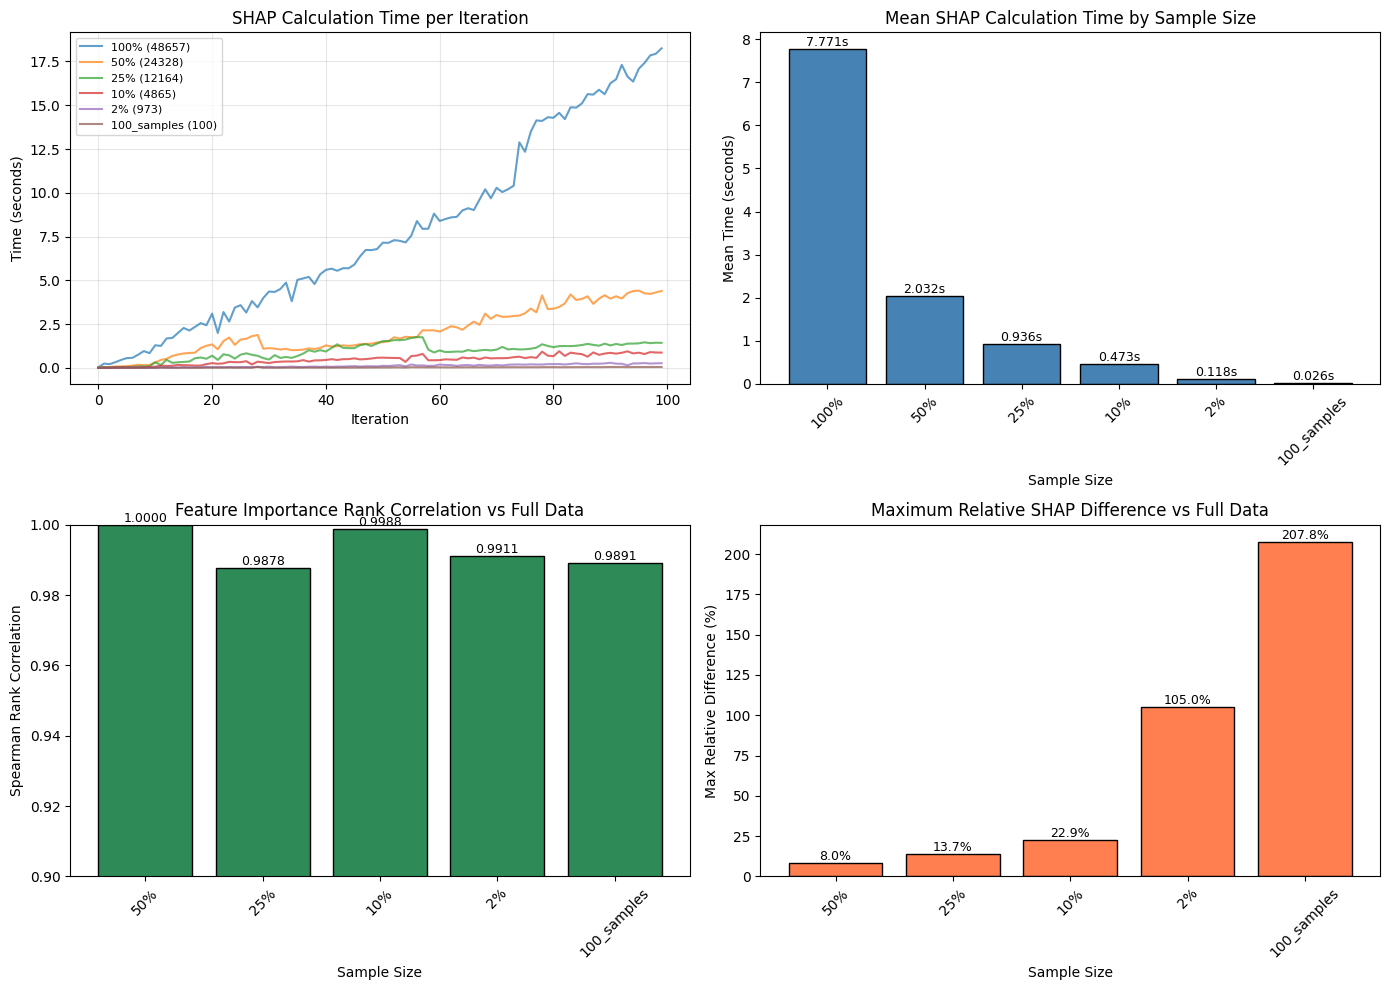

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Timing over iterations for each sample size
ax1 = axes[0, 0]
for name in sample_configs.keys():
    ax1.plot(timing_per_iteration[name], label=f"{name} ({sample_configs[name]})", alpha=0.7)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Time (seconds)")
ax1.set_title("SHAP Calculation Time per Iteration")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Mean timing vs sample size
ax2 = axes[0, 1]
sample_names = list(sample_configs.keys())
mean_times = [np.mean(timing_per_iteration[name]) for name in sample_names]
sample_sizes = [sample_configs[name] for name in sample_names]
ax2.bar(sample_names, mean_times, color='steelblue', edgecolor='black')
ax2.set_xlabel("Sample Size")
ax2.set_ylabel("Mean Time (seconds)")
ax2.set_title("Mean SHAP Calculation Time by Sample Size")
ax2.tick_params(axis='x', rotation=45)
for i, (name, t) in enumerate(zip(sample_names, mean_times)):
    ax2.annotate(f"{t:.3f}s", (i, t), ha='center', va='bottom', fontsize=9)

# Plot 3: Spearman correlation vs sample size
ax3 = axes[1, 0]
correlations = comparison_df["Spearman Rank Corr"].values
sample_labels = comparison_df["Sample Size"].values
ax3.bar(sample_labels, correlations, color='seagreen', edgecolor='black')
ax3.set_xlabel("Sample Size")
ax3.set_ylabel("Spearman Rank Correlation")
ax3.set_title("Feature Importance Rank Correlation vs Full Data")
ax3.set_ylim(min(0.9, min(correlations) - 0.02), 1.0)
ax3.tick_params(axis='x', rotation=45)
for i, (label, corr) in enumerate(zip(sample_labels, correlations)):
    ax3.annotate(f"{corr:.4f}", (i, corr), ha='center', va='bottom', fontsize=9)

# Plot 4: Max relative difference vs sample size
ax4 = axes[1, 1]
max_rel_diffs = comparison_df["Max Rel Diff"].values * 100  # Convert to percentage
ax4.bar(sample_labels, max_rel_diffs, color='coral', edgecolor='black')
ax4.set_xlabel("Sample Size")
ax4.set_ylabel("Max Relative Difference (%)")
ax4.set_title("Maximum Relative SHAP Difference vs Full Data")
ax4.tick_params(axis='x', rotation=45)
for i, (label, diff) in enumerate(zip(sample_labels, max_rel_diffs)):
    ax4.annotate(f"{diff:.1f}%", (i, diff), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [15]:
# Calculate speedup factors vs full data
print("=" * 70)
print("SPEEDUP ANALYSIS")
print("=" * 70)

full_time = np.mean(timing_per_iteration["100%"])
print(f"\nBaseline (100% data): {full_time:.4f}s per iteration")
print("\nSpeedup factors:")
for name in sample_configs.keys():
    if name == "100%":
        continue
    mean_time = np.mean(timing_per_iteration[name])
    speedup = full_time / mean_time
    corr = comparison_df[comparison_df["Sample Size"] == name]["Spearman Rank Corr"].values[0]
    print(f"  {name:12s}: {speedup:6.2f}x faster (rank corr: {corr:.4f})")


SPEEDUP ANALYSIS

Baseline (100% data): 7.7707s per iteration

Speedup factors:
  50%         :   3.82x faster (rank corr: 1.0000)
  25%         :   8.30x faster (rank corr: 0.9878)
  10%         :  16.43x faster (rank corr: 0.9988)
  2%          :  65.65x faster (rank corr: 0.9911)
  100_samples : 295.32x faster (rank corr: 0.9891)


In [16]:
# use_lightgbm_default = True
# use_shap = False

# grid_results = run_grid_search(base_params, grid, use_lightgbm_default, use_shap, 10)
# save_grid_results(grid_results, "../results/grid_search_results_default_100.json", use_lightgbm_default=use_lightgbm_default, use_shap=use_shap, n_folds=10)


In [17]:
# use_lightgbm_default = False
# use_shap = True

# grid_results = run_grid_search(base_params, grid, use_lightgbm_default, use_shap, 10)
# save_grid_results(grid_results, "../results/grid_search_results_100.json", use_lightgbm_default=use_lightgbm_default, use_shap=use_shap, n_folds=10)


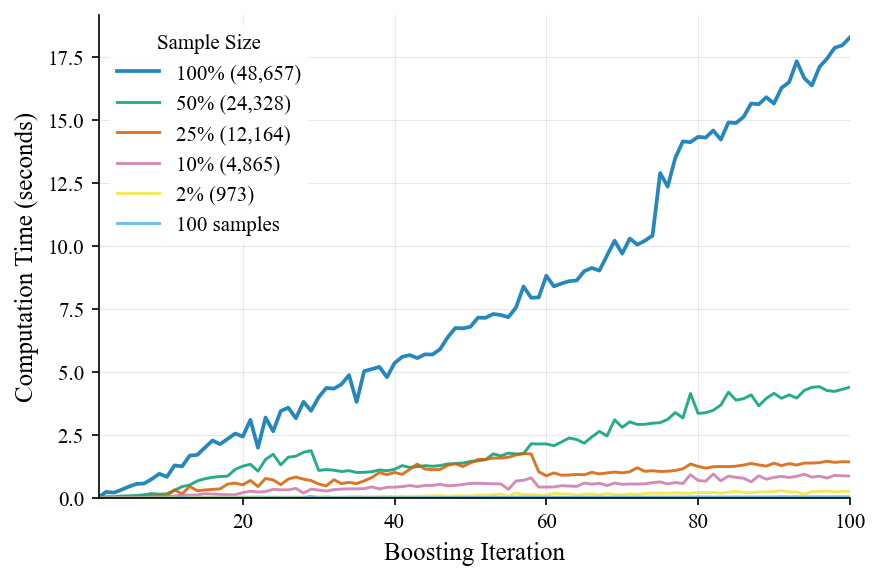

Saved to ../results/shap_timing_per_iteration.pdf and .png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set up publication-quality defaults
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette - colorblind-friendly
colors = {
    "100%": "#0072B2",        # Blue
    "50%": "#009E73",         # Green  
    "25%": "#D55E00",         # Vermillion
    "10%": "#CC79A7",         # Pink
    "2%": "#F0E442",          # Yellow
    "100_samples": "#56B4E9", # Sky blue
}

fig, ax = plt.subplots(figsize=(6, 4))

for name in sample_configs.keys():
    n_samples = sample_configs[name]
    label = f"{n_samples:,} samples" if name == "100_samples" else f"{name} ({n_samples:,})"
    ax.plot(
        range(1, len(timing_per_iteration[name]) + 1),
        timing_per_iteration[name],
        label=label,
        color=colors[name],
        alpha=0.85,
        linewidth=1.8 if name == "100%" else 1.4,
    )

ax.set_xlabel("Boosting Iteration")
ax.set_ylabel("Computation Time (seconds)")
ax.set_xlim(1, len(timing_per_iteration["100%"]))
ax.set_ylim(bottom=0)

# Format y-axis
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

# Legend outside or inside depending on preference
ax.legend(
    loc='upper left',
    frameon=True,
    framealpha=0.95,
    edgecolor='none',
    title='Sample Size',
    title_fontsize=10,
)

# Add subtle grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()

# Save in multiple formats for publication
fig.savefig('../results/shap_timing_per_iteration.pdf', bbox_inches='tight', pad_inches=0.02)
fig.savefig('../results/shap_timing_per_iteration.png', bbox_inches='tight', pad_inches=0.02, dpi=300)

plt.show()

print("Saved to ../results/shap_timing_per_iteration.pdf and .png")